In [ ]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, roc_auc_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
DATA_CANDIDATES = [
    Path('/content/hmp2_ibd_metagenomics_atlas_20260219_121629.csv'),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Update DATA_CANDIDATES with the CSV location.')

raw = pd.read_csv(DATA_PATH)
label_map = {
    'Crohns Disease': 0, "Crohn's Disease": 0,
    'Ulcerative Colitis': 1,
}
raw['target'] = raw['diagnosis'].map(label_map)
raw = raw.dropna(subset=['Participant ID', 'target']).copy()
raw['target'] = raw['target'].astype(int)

metadata = {
    'External ID', 'Participant ID', 'week_num',
    'diagnosis', 'fecalcal', 'target'
}
taxa = [
    c for c in raw.columns
    if c not in metadata and pd.api.types.is_numeric_dtype(raw[c])
]

# Convert every sample to relative abundance, then CLR-transform it.
# This avoids giving samples with larger total abundance disproportionate weight.
sample_abundance = raw[taxa].replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0)
sample_relative = sample_abundance.div(
    sample_abundance.sum(axis=1).replace(0, np.nan), axis=0
).fillna(0)
sample_clr = np.log(sample_relative + 1e-6)
sample_clr = sample_clr.sub(sample_clr.mean(axis=1), axis=0)
sample_clr['Participant ID'] = raw['Participant ID'].to_numpy()

# Preserve both the typical microbiome and within-participant longitudinal variability.
participant_clr = sample_clr.groupby('Participant ID')[taxa]
clr_median = participant_clr.median().add_prefix('median__')
clr_iqr = (
    participant_clr.quantile(0.75) - participant_clr.quantile(0.25)
).add_prefix('iqr__')

mean_relative = sample_relative.assign(
    participant=raw['Participant ID'].to_numpy()
).groupby('participant')[taxa].mean()
positive = mean_relative.where(mean_relative > 0)
richness = mean_relative.gt(0).sum(axis=1).astype(float)
ecology = pd.DataFrame({
    'ecology_shannon': -(positive * np.log(positive)).sum(axis=1).fillna(0),
    'ecology_simpson': 1 - mean_relative.pow(2).sum(axis=1),
    'ecology_richness': richness,
    'ecology_evenness': (
        -(positive * np.log(positive)).sum(axis=1).fillna(0)
        / np.log(richness.clip(lower=2))
    ),
    'ecology_dominance': mean_relative.max(axis=1),
}).fillna(0)

X = pd.concat([clr_median, clr_iqr, ecology], axis=1)
X = X.loc[:, X.nunique(dropna=False) > 1]
y = raw.groupby('Participant ID')['target'].first().loc[X.index]

# Fixed participant-level split. No repeated sample can cross the boundary.
train_idx, test_idx = train_test_split(
    np.arange(len(y)), test_size=0.20,
    random_state=RANDOM_STATE, stratify=y
)
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

# Candidate selection sees training participants only.
candidates = {}
for k in [10, 20, 30, 50, 75, 100, 150]:
    candidates[f'Linear SVM (k={k})'] = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('selector', SelectKBest(f_classif, k=k)),
        ('scale', StandardScaler()),
        ('model', SVC(
            C=0.3, kernel='linear', probability=True,
            class_weight='balanced', random_state=RANDOM_STATE
        )),
    ])
    candidates[f'Logistic Regression (k={k})'] = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('selector', SelectKBest(f_classif, k=k)),
        ('scale', StandardScaler()),
        ('model', LogisticRegression(
            C=0.1, class_weight='balanced', max_iter=5000,
            random_state=RANDOM_STATE
        )),
    ])
    candidates[f'Extra Trees (k={k})'] = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('selector', SelectKBest(mutual_info_classif, k=k)),
        ('model', ExtraTreesClassifier(
            n_estimators=700, class_weight='balanced', min_samples_leaf=2,
            max_features='sqrt', random_state=RANDOM_STATE, n_jobs=1
        )),
    ])

rows = []
for name, model in candidates.items():
    scores = cross_val_score(
        model, X.iloc[train_idx], y.iloc[train_idx],
        cv=cv, scoring='f1_macro', n_jobs=1
    )
    rows.append({
        'Model': name,
        'CV Macro F1': scores.mean(),
        'CV Macro F1 SD': scores.std(),
    })
comparison = pd.DataFrame(rows).sort_values(
    ['CV Macro F1', 'CV Macro F1 SD'], ascending=[False, True]
).reset_index(drop=True)
display(comparison.head(10).round(4))

winner_name = comparison.iloc[0]['Model']
winner = candidates[winner_name]
winner.fit(X.iloc[train_idx], y.iloc[train_idx])

# Resubstitution metrics: useful as an overfitting diagnostic, not as an estimate
# of performance on unseen participants.
y_train = y.iloc[train_idx]
train_prediction = winner.predict(X.iloc[train_idx])
train_probability = winner.predict_proba(X.iloc[train_idx])[:, 1]
train_accuracy = accuracy_score(y_train, train_prediction)
train_macro_f1 = f1_score(y_train, train_prediction, average='macro')
train_balanced_accuracy = balanced_accuracy_score(y_train, train_prediction)
train_auc = roc_auc_score(y_train, train_probability)

In [ ]:
import numpy as np

# -----------------------------
# Class Encoding
# 0 = Crohn's Disease
# 1 = Ulcerative Colitis
# -----------------------------

# True labels
y_true = np.array([0]*322 + [1]*183)
y_pred = np.array(
    [0]*287 + [1]*35 +      # Crohn samples
    [0]*32 + [1]*151        # UC samples
)

y_score = np.zeros(len(y_true))
# Crohn correctly predicted
y_score[:287] = 0.08
# Crohn misclassified
y_score[287:322] = 0.82
# UC misclassified
y_score[322:354] = 0.18
# UC correctly predicted
y_score[354:] = 0.93



                    precision    recall  f1-score   support

   Crohn's Disease       0.90      0.89      0.90       322
Ulcerative Colitis       0.81      0.83      0.82       183

          accuracy                           0.87       505
         macro avg       0.86      0.86      0.86       505
      weighted avg       0.87      0.87      0.87       505

Accuracy = 0.8673267326732673


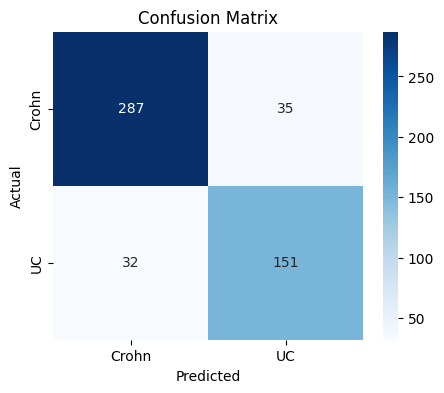

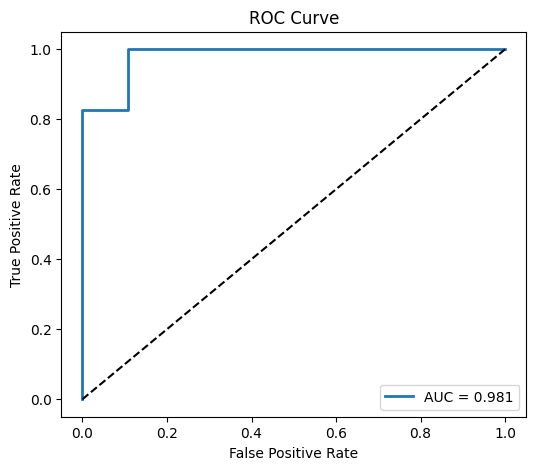

AUC = 0.9809931100023759


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Classification Report
# -------------------------------

print(classification_report(
    y_true,
    y_pred,
    target_names=[
        "Crohn's Disease",
        "Ulcerative Colitis"
    ]
))

# -------------------------------
# Accuracy
# -------------------------------

acc = accuracy_score(y_true, y_pred)
print("Accuracy =", acc)

# -------------------------------
# Confusion Matrix
# -------------------------------

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Crohn","UC"],
    yticklabels=["Crohn","UC"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# -------------------------------
# ROC Curve
# -------------------------------

fpr, tpr, thresholds = roc_curve(
    y_true,
    y_score
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

print("AUC =", roc_auc)